1.1 The operator (Hamiltonian)

In [6]:
from qiskit.quantum_info import SparsePauliOp
# Sparse N-qubit operator in a Pauli basis

hamiltonian = SparsePauliOp(
    [
        "IIII",
        "IIIZ",
        "IZII",
        "IIZI",
        "ZIII",
        "IZIZ",
        "IIZZ",
        "ZIIZ",
        "IZZI",
        "ZZII",
        "ZIZI",
        "YYYY",
        "XXYY",
        "YYXX",
        "XXXX",
    ],
    coeffs=[
        -0.09820182 + 0.0j,
        -0.1740751 + 0.0j,
        -0.1740751 + 0.0j,
        0.2242933 + 0.0j,
        0.2242933 + 0.0j,
        0.16891402 + 0.0j,
        0.1210099 + 0.0j,
        0.16631441 + 0.0j,
        0.16631441 + 0.0j,
        0.1210099 + 0.0j,
        0.17504456 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
    ],
)
# Hamiltonian for a simple Hydrogen molecule; Jordan-Wigner mapper
# Constructing a Hamiltonian for four qubits by tensor products of the Pauli matrices, number of Pauli
# matrices determined by the number of qubits

# ???? Grouping, commutation
# A Hamiltonian generally cannot be estimated all at once. We split up the basis into multiple
# groups to be estimated separately and finallly combine the results.

In [7]:
import numpy as np

A = np.array(hamiltonian) # Make the H into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
# Use classical eigensolver to find the eigenvalues and eigenvectors of a Hermitian matrix
print("The ground state energy is ", min(eigenvalues), "hartrees")

The ground state energy is  -1.1459778447627311 hartrees


3. Example Hamiltonian

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [10]:
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
) # Building the small hamiltonian from Pauli strings (N_{GCP} = 3)

A = np.array(hamiltonian) # making the Hamiltonian into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is: ", min(eigenvalues))

The ground state energy is:  -0.7029303944595311


This circuit has 4 parameters


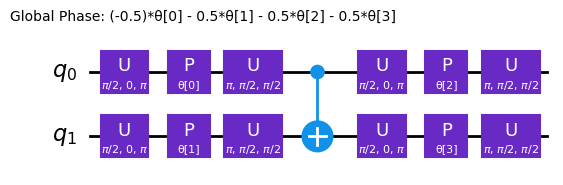

In [11]:
from qiskit.circuit.library import efficient_su2 # importing a prefabricated ansatz circuit and operator class

ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1

)

# input the number of qubits, gates to apply to each qubit, and entanglement structure. reps: number of repetition 
# after entanglement. SU(2): Special Unitary 2-D matrices
# Use the CNOT gate as the entangler. Circular entanglement is a linear entanglement and the connection between the last and the first.
# Angles are Euler angles with the Z-Y-Z convention for U gates; 
num_parameters = ansatz.num_parameters
print("This circuit has", num_parameters, "parameters")
ansatz.decompose().draw("mpl", style="textbook") # drawing with matplotlib in textbook style

In [12]:
# from qiskit_ibm_runtime import QiskitRuntimeService, Session
# from qiskit_ibm_runtime import EstimatorV2 as Estimator

# service = QiskitRuntimeService()
# backend = service.least_busy(operational=1, simulator=1)

# print(backend)

## No account yet.

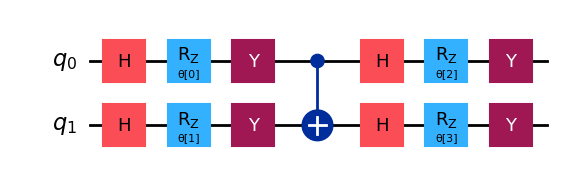

In [76]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# target = backend.target
pm = generate_preset_pass_manager(optimization_level=3)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

# transpile the ansatz for our hardware and visualize

In [78]:
from qiskit.primitives import StatevectorEstimator as Estimator
# Local estimator
estimator = Estimator()

In [80]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
# Mapping the Hamiltonian to match the qubits

In [82]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

# Defining a function that returns the cost function associated with an ansatz and params.

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

# Tracking the history of cost functions for convergence analysis

In [84]:
x0 = 2 * np.pi * np.random.random(num_parameters)
# Choosing random initial parameters. np.random.random returns an array of random numbers between [0.0, 1.0)

In [86]:
res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 50},
)

Iters. done: 1 [Current cost: 0.13164358075291932]
Iters. done: 2 [Current cost: 0.11895064204593042]
Iters. done: 3 [Current cost: 0.43760730170026696]
Iters. done: 4 [Current cost: 0.20037513074261099]
Iters. done: 5 [Current cost: 0.41706305611537275]
Iters. done: 6 [Current cost: -0.3849589485360431]
Iters. done: 7 [Current cost: -0.5639947065187942]
Iters. done: 8 [Current cost: -0.16595036026640364]
Iters. done: 9 [Current cost: -0.5385834822166378]
Iters. done: 10 [Current cost: -0.46139097986400357]
Iters. done: 11 [Current cost: -0.6072709849831498]
Iters. done: 12 [Current cost: -0.5392257146640196]
Iters. done: 13 [Current cost: -0.6506288325129109]
Iters. done: 14 [Current cost: -0.6492236150694692]
Iters. done: 15 [Current cost: -0.6046929778368869]
Iters. done: 16 [Current cost: -0.6681390281901964]
Iters. done: 17 [Current cost: -0.6677927003350204]
Iters. done: 18 [Current cost: -0.6422012392058173]
Iters. done: 19 [Current cost: -0.6837722954172396]
Iters. done: 20 [Cu

In [88]:
cost_history_dict

{'prev_vector': array([1.60181848, 0.97379008, 6.28574249, 4.71599314]),
 'iters': 50,
 'cost_history': [0.13164358075291932,
  0.11895064204593042,
  0.43760730170026696,
  0.20037513074261099,
  0.41706305611537275,
  -0.3849589485360431,
  -0.5639947065187942,
  -0.16595036026640364,
  -0.5385834822166378,
  -0.46139097986400357,
  -0.6072709849831498,
  -0.5392257146640196,
  -0.6506288325129109,
  -0.6492236150694692,
  -0.6046929778368869,
  -0.6681390281901964,
  -0.6677927003350204,
  -0.6422012392058173,
  -0.6837722954172396,
  -0.6875122173203387,
  -0.654202761757048,
  -0.68505293218818,
  -0.6790013388639845,
  -0.6903349257356831,
  -0.6926407238170953,
  -0.6859612503750924,
  -0.6885220507493861,
  -0.6987211684698434,
  -0.7011606214922508,
  -0.701363318059641,
  -0.702679173728895,
  -0.7000769218294587,
  -0.7002380882041733,
  -0.7015920167447527,
  -0.7022312392046617,
  -0.702195142807181,
  -0.7027029263863599,
  -0.7026152869791139,
  -0.7026852370117292,
  -0

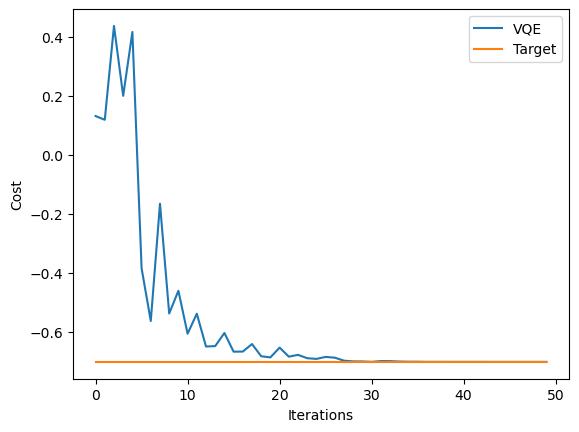

In [90]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 50)

# Define the constant function
constant = min(eigenvalues)
y_constant = np.full_like(x, constant)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()